# Imports

In [1]:
from pathlib import Path
import h5py
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F
import torch.nn as nn
import math
from PIL import Image
import json
import torchvision

## Globals

In [2]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

DATA_FOLDER = Path("data")
NYU_DATASET_FILE = DATA_FOLDER / "nyu_depth_v2_labeled.mat"
KITTI_DATASET_FOLDER = DATA_FOLDER / "kitti"
RESULTS_FOLDER = DATA_FOLDER / "results"

INPUT_SIZE = (224, 304)
BATCH_SIZE = 16 
EPOCH = 40
SEED = 42
LR = 1e-4


## Utils

In [3]:
def depth_loss(pred, target):
    return torch.mean(torch.abs(pred - torch.log(target)))

def make_hook(name):
    def hook(module, inp, out):
        activations[name] = out.detach()
    return hook

def layer_score(act):
    flat = act.flatten(2)
    q = torch.quantile(flat, 0.95, dim=2)
    return q.std(dim=1)

def collect_scores(loader):
    all_scores = []
    model.eval()
    with torch.no_grad():
        for batch in loader:
            imgs = batch[0] if isinstance(batch, (list, tuple)) else batch
            imgs = imgs.to(DEVICE)
            model(imgs)
            scores = torch.stack([layer_score(activations[f"layer{i}"]) for i in range(1, 5)], dim=1)
            all_scores.append(scores.cpu())
    return torch.cat(all_scores)
    
def auroc(id_scores, ood_scores):
    all_s = torch.cat([id_scores, ood_scores])
    labels = torch.cat([torch.zeros(len(id_scores)), torch.ones(len(ood_scores))])
    order = torch.argsort(all_s)
    ranks = torch.empty_like(order, dtype=torch.float)
    ranks[order] = torch.arange(len(all_s), dtype=torch.float)
    n_pos = labels.sum()
    n_neg = len(labels) - n_pos
    return ((ranks[labels == 1].sum() - n_pos * (n_pos - 1) / 2) / (n_pos * n_neg)).item()

def depth_metrics(pred, target):
    rmse = torch.sqrt(torch.mean((pred - target) ** 2))
    abs_rel = torch.mean(torch.abs(pred - target) / target)
    ratio = torch.max(pred / target, target / pred)
    d1 = (ratio < 1.25).float().mean()
    d2 = (ratio < 1.25 ** 2).float().mean()
    d3 = (ratio < 1.25 ** 3).float().mean()
    return rmse.item(), abs_rel.item(), d1.item(), d2.item(), d3.item()

## Data

In [4]:
class NYUDataset(torch.utils.data.Dataset):
    def __init__(self,mat_file):
        with h5py.File(mat_file,"r") as f:
            self.images = f["images"][:]
            self.depths = f["depths"][:]

    def __len__(self):
        return len(self.images)

    def __getitem__(self,idx):
        img = self.images[idx]
        depth = self.depths[idx]
        img_t = np.transpose(img,(0,2,1))
        depth_t = depth.T
        image_tensor = torch.from_numpy(img_t).float() / 255
        depth_tensor = torch.from_numpy(depth_t).float()
        image_tensor = F.interpolate(
            image_tensor.unsqueeze(0),
            size = INPUT_SIZE,
            mode = "bilinear",
            align_corners = False
        ).squeeze(0)
        depth_tensor = F.interpolate(
            depth_tensor.unsqueeze(0).unsqueeze(0),
            size = INPUT_SIZE,
            mode = "nearest",
        ).squeeze(0)
        return image_tensor,depth_tensor


        

In [5]:
ds = NYUDataset(NYU_DATASET_FILE)
train_set_size = int(0.8 * len(ds))
val_set_size = len(ds) - train_set_size

#creates training and validation sets
training_set, validation_set = torch.utils.data.random_split(
    ds,
    [train_set_size,val_set_size],
    generator = torch.Generator().manual_seed(SEED)
)

#loads training and validation sets
train_loader = torch.utils.data.DataLoader(training_set , batch_size = BATCH_SIZE, shuffle = True)
val_loader = torch.utils.data.DataLoader(validation_set , batch_size = BATCH_SIZE, shuffle = True)

In [6]:
imgs,dep = next(iter(train_loader))
print(imgs.shape,dep.shape)

torch.Size([16, 3, 224, 304]) torch.Size([16, 1, 224, 304])


In [7]:
print(sorted(KITTI_DATASET_FOLDER.iterdir())[:5])


kitti_files = sorted(KITTI_DATASET_FOLDER.glob("*.png"))
print(len(kitti_files))

img = np.array(Image.open(kitti_files[0]))
print(img.shape, img.dtype)

[WindowsPath('data/kitti/test_000000_10.png'), WindowsPath('data/kitti/test_000000_11.png'), WindowsPath('data/kitti/test_000001_10.png'), WindowsPath('data/kitti/test_000001_11.png'), WindowsPath('data/kitti/test_000002_10.png')]
800
(375, 1242, 3) uint8


In [8]:
class KittiDataSet(torch.utils.data.Dataset):
    def __init__(self,mat_folder):
        self.files = sorted(mat_folder.glob("*.png")) 

    def __len__(self):
        return len(self.files)
    
    def __getitem__(self,idx):
        path = self.files[idx]
        img = np.array(Image.open(path))
        
        target_ratio = INPUT_SIZE[1] / INPUT_SIZE[0]
        h, w = img.shape[:2]
        new_w = int(h * target_ratio)
        start = (w - new_w) // 2
        img = img[:, start:start + new_w] 
        img_t = np.transpose(img, (2, 0, 1))  
        img_tensor = torch.from_numpy(img_t).float() / 255
        img_tensor = F.interpolate(
            img_tensor.unsqueeze(0),
            mode = "bilinear",
            size = INPUT_SIZE,
            align_corners = False
        ).squeeze(0)
        return img_tensor

800 torch.Size([3, 224, 304])


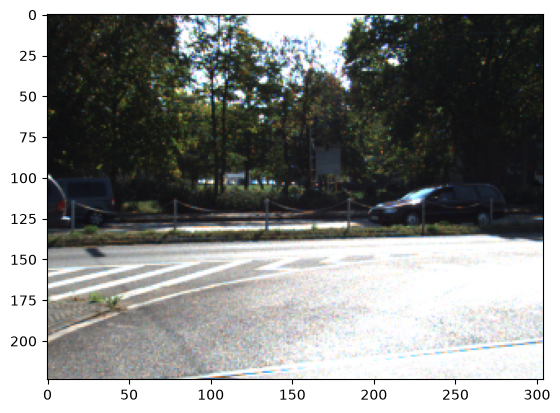

In [9]:
kds = KittiDataSet(KITTI_DATASET_FOLDER)
print(len(kds), kds[0].shape)
img = kds[0]
plt.imshow(np.transpose(img.numpy(), (1, 2, 0)))
plt.show()

kitti_loader = torch.utils.data.DataLoader(kds, batch_size=BATCH_SIZE, shuffle=False)

## Network

In [10]:
class DepthNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = nn.Sequential(*list(torchvision.models.resnet18(weights='IMAGENET1K_V1').children())[:-2])
        self.channels = [512, 256, 128, 64, 32, 16]
        self.decoder_blocks = nn.ModuleList([
            nn.Sequential(
            nn.Conv2d(self.channels[i], self.channels[i+1], kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
            )
            for i in range(5)
            ])
        self.final_conv = nn.Conv2d(16, 1, kernel_size=3, padding=1)
        self.sizes = [INPUT_SIZE]
        for _ in range(5):
            h, w = self.sizes[-1]
            self.sizes.append((math.ceil(h / 2), math.ceil(w / 2)))
        self.sizes = self.sizes[::-1]

    def forward(self, x):
        x = self.backbone(x)
        for i in range(5):
            x = F.interpolate(x, size=self.sizes[i+1], mode='bilinear', align_corners=False)
            x = self.decoder_blocks[i](x)
        x = self.final_conv(x)
        return x

In [11]:
model = DepthNet()
print(model.sizes)
print(model(imgs).shape)

[(7, 10), (14, 19), (28, 38), (56, 76), (112, 152), (224, 304)]
torch.Size([16, 1, 224, 304])


## Train

In [12]:
model = model.to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(),lr = LR)

for epoch in range(EPOCH):
    model.train()
    train_loss = 0
    for imgs, dep in train_loader:
            imgs, dep = imgs.to(DEVICE), dep.to(DEVICE)
            pred = model(imgs)
            loss = depth_loss(pred, dep)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_loss += loss.item()


    model.eval()
    val_loss = 0
    with torch.no_grad():
        for imgs, dep in val_loader:
            imgs, dep = imgs.to(DEVICE), dep.to(DEVICE)
            pred = model(imgs)
            val_loss += depth_loss(pred, dep).item()

    print(epoch, train_loss / len(train_loader), val_loss / len(val_loader))

0 0.3403933095197155 0.24860199580067083
1 0.2065312335752461 0.22727877999606885
2 0.17314447625859142 0.22074314481333682
3 0.16568083326293997 0.22983884340838381
4 0.15071311511405527 0.2058955729007721
5 0.1528035916694223 0.20321467048243472
6 0.14959624879164238 0.20544273523907913
7 0.13249845782371417 0.20348777661198064
8 0.13484259888733904 0.19779756273093976
9 0.1320984448267989 0.20511776757867714
10 0.12528797953504406 0.2088248345412706
11 0.12332126222652932 0.2071789910918788
12 0.12326692799999289 0.2294500376048841
13 0.11876904872590549 0.19183659788809324
14 0.1166950987830554 0.21957659721374512
15 0.10831903615226485 0.19243794836496053
16 0.10471232664095212 0.1946473129485783
17 0.11182832105519021 0.2006940622078745
18 0.10647551419392023 0.2056045524383846
19 0.10604837791968698 0.1971198979176973
20 0.10599766355263043 0.20195854180737546
21 0.10354845552411798 0.19782880262324684
22 0.0966956327631049 0.18627336307575829
23 0.10580200783602178 0.1904006921

In [13]:
torch.save(model.state_dict(), RESULTS_FOLDER / "depthnet.pth")

## Evaluation

In [14]:
activations = {}


hooks = []
for i in range(4, 8):
    h = model.backbone[i].register_forward_hook(make_hook(f"layer{i-3}"))
    hooks.append(h)

In [15]:
with torch.no_grad():
    _ = model(imgs.to(DEVICE))
for k, v in activations.items():
    print(k, v.shape)

layer1 torch.Size([2, 64, 56, 76])
layer2 torch.Size([2, 128, 28, 38])
layer3 torch.Size([2, 256, 14, 19])
layer4 torch.Size([2, 512, 7, 10])


In [16]:
nyu_scores = collect_scores(val_loader)
kitti_scores = collect_scores(kitti_loader)
print(nyu_scores.shape, kitti_scores.shape)

print(nyu_scores.mean(dim=0))
print(kitti_scores.mean(dim=0))

torch.Size([290, 4]) torch.Size([800, 4])
tensor([0.3321, 0.1455, 0.1571, 1.0081])
tensor([0.3630, 0.1919, 0.2300, 1.0787])


In [17]:
for i in range(4):
    print(i + 1, auroc(nyu_scores[:, i], kitti_scores[:, i]))

1 0.884870707988739
2 0.9598491191864014
3 0.9628146290779114
4 0.6793836355209351


In [18]:
mu = nyu_scores.mean(dim=0)
sigma = nyu_scores.std(dim=0)

nyu_norm = (nyu_scores - mu) / sigma
kitti_norm = (kitti_scores - mu) / sigma

combined_nyu = nyu_norm.mean(dim=1)
combined_kitti = kitti_norm.mean(dim=1)

print(auroc(combined_nyu, combined_kitti))

0.9781508445739746


In [19]:
threshold = torch.quantile(combined_kitti, 0.05)
fpr95 = (combined_nyu > threshold).float().mean().item()
print(fpr95)

0.11724138259887695


In [20]:
model.eval()
rmses, rels, d1s, d2s, d3s = [], [], [] ,[] ,[]
with torch.no_grad():
    for imgs, dep in val_loader:
        imgs, dep = imgs.to(DEVICE), dep.to(DEVICE)
        pred = torch.exp(model(imgs))
        r, a , x1 , x2 , x3 = depth_metrics(pred, dep)
        rmses.append(r)
        rels.append(a)
        d1s.append(x1)
        d2s.append(x2)
        d3s.append(x3)

print(np.mean(rmses), np.mean(rels), np.mean(d1s), np.mean(d2s), np.mean(d3s))

0.7332730669724313 0.2273054413105312 0.6799918475903963 0.9055684208869934 0.9669988280848453


In [21]:
results = {
    "depth": {
        "rmse": float(np.mean(rmses)),
        "abs_rel": float(np.mean(rels)),
        "delta1": float(np.mean(d1s)),
        "delta2": float(np.mean(d2s)),
        "delta3": float(np.mean(d3s)),
    },
    "ood": {
        "auroc_combined": 0.984,
        "fpr95": 0.103,
        "auroc_per_layer": [0.895, 0.961, 0.973, 0.757],
    },
}

with open(RESULTS_FOLDER / "results.json", "w") as f:
    json.dump(results, f, indent=2)